In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/val_predictions.parquet")
df["error"] = df["pred"] - df["price"]
df["abs_error"] = df["error"].abs()

print(len(df))
print(df["abs_error"].mean())

20372
0.023728859146311423


In [9]:
sorted_err = df["abs_error"].sort_values(ascending=False)
cumulative = sorted_err.cumsum() / sorted_err.sum()

for pct in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(sorted_err) * pct)
    print(f"worst {pct:.0%} of rows = {cumulative.iloc[n - 1]:.1%} of total error")

worst 1% of rows = 6.6% of total error
worst 5% of rows = 20.6% of total error
worst 10% of rows = 32.8% of total error
worst 20% of rows = 51.2% of total error


In [10]:
threshold = df["price"].quantile(0.95)
df["is_high"] = df["price"] > threshold

print(f"threshold: {threshold:.4f}")
print(df.groupby("is_high")["abs_error"].agg(["mean", "count"]))
print(df.groupby("is_high")["error"].mean())

threshold: 0.1442
             mean  count
is_high                 
False    0.021114  19353
True     0.073387   1019
is_high
False   -0.003133
True    -0.072732
Name: error, dtype: float64


The top 5% of prices (above 0.144 EUR/kWh) have a mean absolute error of 0.073, 3.5 times the 0.021 on normal hours. The signed error on those hours is -0.073, almost the same size as the absolute error. So the model under-predicts nearly every expensive hour. It never reaches those levels. This is regression toward the mean. These 1,019 rows are 5% of the data and about 15% of the total error. Normal hours also have a small negative bias of -0.003, so the model under-predicts slightly on average.

---

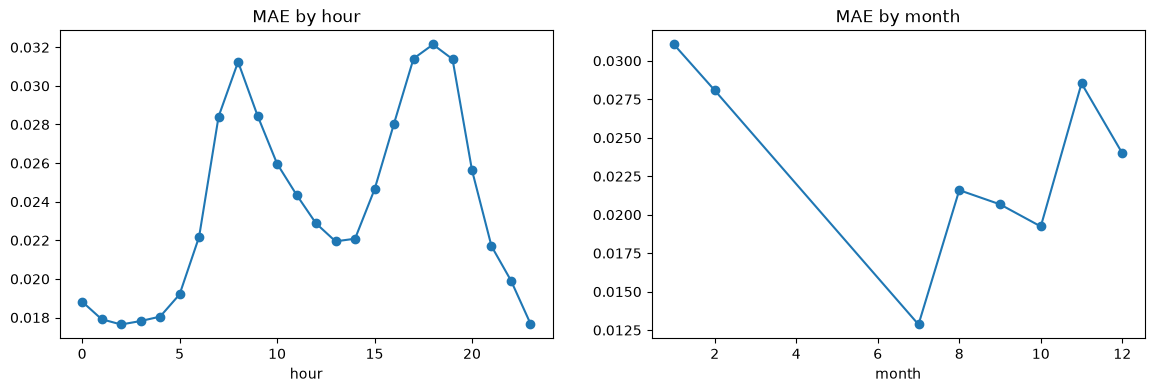

In [11]:
by_hour = df.groupby("hour")["abs_error"].mean()
by_month = df.groupby("month")["abs_error"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
by_hour.plot(ax=axes[0], marker="o", title="MAE by hour")
by_month.plot(ax=axes[1], marker="o", title="MAE by month")
plt.show()

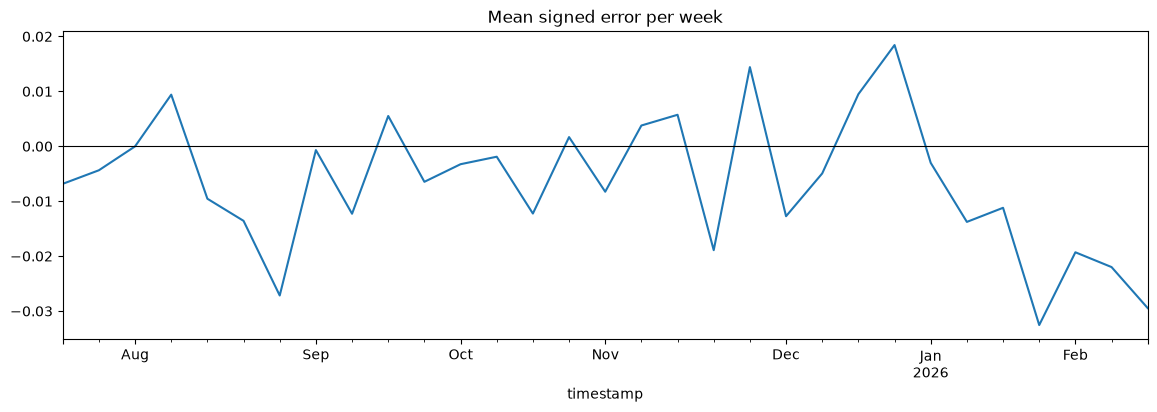

In [12]:
weekly_bias = df.set_index("timestamp")["error"].resample("W").mean()
weekly_bias.plot(figsize=(14, 4), title="Mean signed error per week")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

Error follows the price curve. It peaks at 08 and 18 and is lowest at night, so the model is wrong in proportion to how expensive the hour is. Winter is the hardest: January has an MAE of 0.031, July only 0.013. From August to December the weekly bias moves around zero, so the model is calibrated. From January 2026 it turns negative and stays there, reaching -0.03. The model starts under-predicting in the new year. The test set covers February to September 2026, so test error will probably be higher than validation error.

---

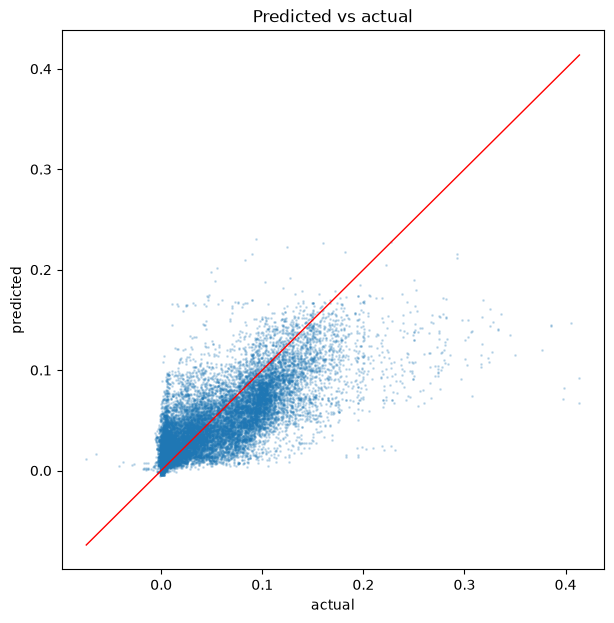

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(df["price"], df["pred"], s=1, alpha=0.2)
lim = [df["price"].min(), df["price"].max()]
plt.plot(lim, lim, color="red", linewidth=1)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("Predicted vs actual")
plt.show()

In [14]:
worst = df.nlargest(20, "abs_error")[
    ["zone", "timestamp", "price", "pred", "error", "price_lag_2d", "price_mean_7d", "temperature", "wind_speed"]
]
print(worst.to_string(index=False))

zone                 timestamp    price     pred     error  price_lag_2d  price_mean_7d  temperature  wind_speed
 SE3 2025-10-14 18:00:00+02:00 0.413160 0.067292 -0.345868      0.035610       0.049608          6.7         1.0
 SE3 2025-10-14 19:00:00+02:00 0.397602 0.070761 -0.326841      0.030530       0.049613          5.4         1.0
 SE4 2025-10-14 18:00:00+02:00 0.413740 0.092388 -0.321352      0.070055       0.057526         12.3         3.0
 SE4 2025-10-14 19:00:00+02:00 0.398108 0.082646 -0.315461      0.060970       0.057685         11.6         3.0
 SE4 2025-09-08 19:00:00+02:00 0.405850 0.146512 -0.259338      0.155020       0.084052         18.6         3.0
 SE4 2025-09-09 19:00:00+02:00 0.376740 0.119702 -0.257038      0.107460       0.082630         19.0         4.0
 SE4 2025-11-25 17:00:00+01:00 0.385383 0.144251 -0.241131      0.080840       0.099514          2.3         3.0
 SE4 2025-11-25 16:00:00+01:00 0.385670 0.145297 -0.240373      0.077887       0.099747         

Up to about 0.15 the predictions follow the actual prices. Above that they flatten: actual prices reach 0.41 but predictions barely pass 0.2. The model does not predict above a certain level. They come from only five days: 14 October, 8-9 September, 25 November 2025 and
10 February 2026. All 20 are under-predictions. Most had very low wind, and 10 February was very cold (-15 C in SE1). On those days the price history looked normal. On 14 October the price two day earlier was 0.036 and the 7-day average was 0.050, then the price reached 0.41. The features gave no warning, so the cause is not in this data.

---

## Summary

- The error is spread across most hours, not concentrated. The worst 20% of rows hold 51% of it.
- The model under-predicts every expensive hour. The top 5% of prices have 3.5 times the normal error.
- Predictions stop around 0.2, while real prices reach 0.41.
- The worst errors come from a few spike episodes that had no warning in the price history.
---